In [1]:
!nvidia-smi

Sun Oct 27 07:23:36 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   37C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

# CONCRETE STRENGTH PREDICTION USING ANN

- Regression is a type of supervised machine learning algorithm used to predict a continuous label. The goal is to produce a model that represents the 'best fit' to some observed data, according to an evaluation criterion.


- In this Analysis, you will be predicting the strength of concrete using the given eight features that describe the components used in the mixture.These features are believed to be related to the final compressive strength which include the amount of cement in Kilograms per cubic meter, Blast.Furnace.Slag, Fly.Ash, water,superplasticizer, coarse aggregate, fine aggregate and aging period measured in days.

## Importing Libraries

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import  callbacks
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error as mae
import seaborn as sns
%matplotlib inline

#removing warnings
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

In [ ]:
!nvidia-smi

In [3]:
print(tensorflow.__version__)

2.17.0


## Import Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
os.chdir("/content/drive/MyDrive/Deep Learning Project /2. Regression Using ANN")

In [6]:
pwd

'/content/drive/MyDrive/Deep Learning Project /2. Regression Using ANN'

In [7]:
df = pd.read_csv('concrete_data.csv')
df.shape

(1030, 9)

The dataset contains 1030 observations accross 8 input variables and an output variable. The variable name, variable type, the measurement unit and a brief description is provided.

In [8]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


### There are 8 independent variables in training set:

- Cement: Total amount of cement it that particular sample.
- Blast Furnace Slag:  Blast furnace slag (BFS) is a byproduct of the iron and steel manufacturing process. BFS is used to improve the strength and durability of concrete.
- FlyAsh :  It improves the strength and durability of the concrete.
- Water: The optimal water content for cement is usually between 15-20% of the total cement weight. Too little water will result in a dry, crumbly mix, while too much water can lead to a weak, porous concrete.
- Superplasticizer:  Superplasticizers, also known as plasticizers or high range water reducers, are a type of admixture that is used to increase the workability of concrete without increasing the water-cement ratio.
- CoarseAggregatet:  Coarse aggregate is used for a variety of purposes, including providing strength, improving the workability of concrete, and reducing the amount of cement needed in a concrete mix.
- FineAggregate:  Similar as CoarseAggregateComponent but smaller in size.
- Age:  Age in days is a term used to describe the amount of time that has passed since the cement was mixed with water. Concrete gains strength over time and its properties can change significantly depending on the age. The most commonly used ages for testing concrete strength are 7, 14, 21, and 28 days.

### Target varibale:

- Strength:  Strength of the cement.

## Exploratory Data Analysis

In [ ]:
df.isna().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [ ]:
# Summary statistics
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


All predictors in the dataset are quantitative datatypes. Moreover, there are no missing values in the data. Lets analyse the probability distribution of the variables through a series of univariate density plots.

In [10]:

def create_distplot(dataset, columns, rows, cols, title):
    """
    Objective: Create Distrubitions of all variables

    Params:
    --------
        dataset: input pandas dataset
        columns: list, all columns list
        rows: how many number of rows we want to plot
        cols: how many number of cols we want to plot
        tittle:  name for all the plots
    Returns:
    """
    fig, axs = plt.subplots(rows, cols,figsize=(16,16))
    fig.suptitle(title,y=0.92, size=16)
    axs = axs.flatten()
    for i, data in enumerate(columns):
        sns.distplot(dataset[data], ax=axs[i])
        axs[i].set_title(data + ', skewness is '+str(round(dataset[data].skew(axis = 0, skipna = True),2)))

<ipython-input-10-55ab0a2b5963>:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[data], ax=axs[i])
<ipython-input-10-55ab0a2b5963>:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[data], ax=axs[i])
<ipython-input-10-55ab0a2b5963>:18: UserWarning: 

`distplot` is a deprecated fu

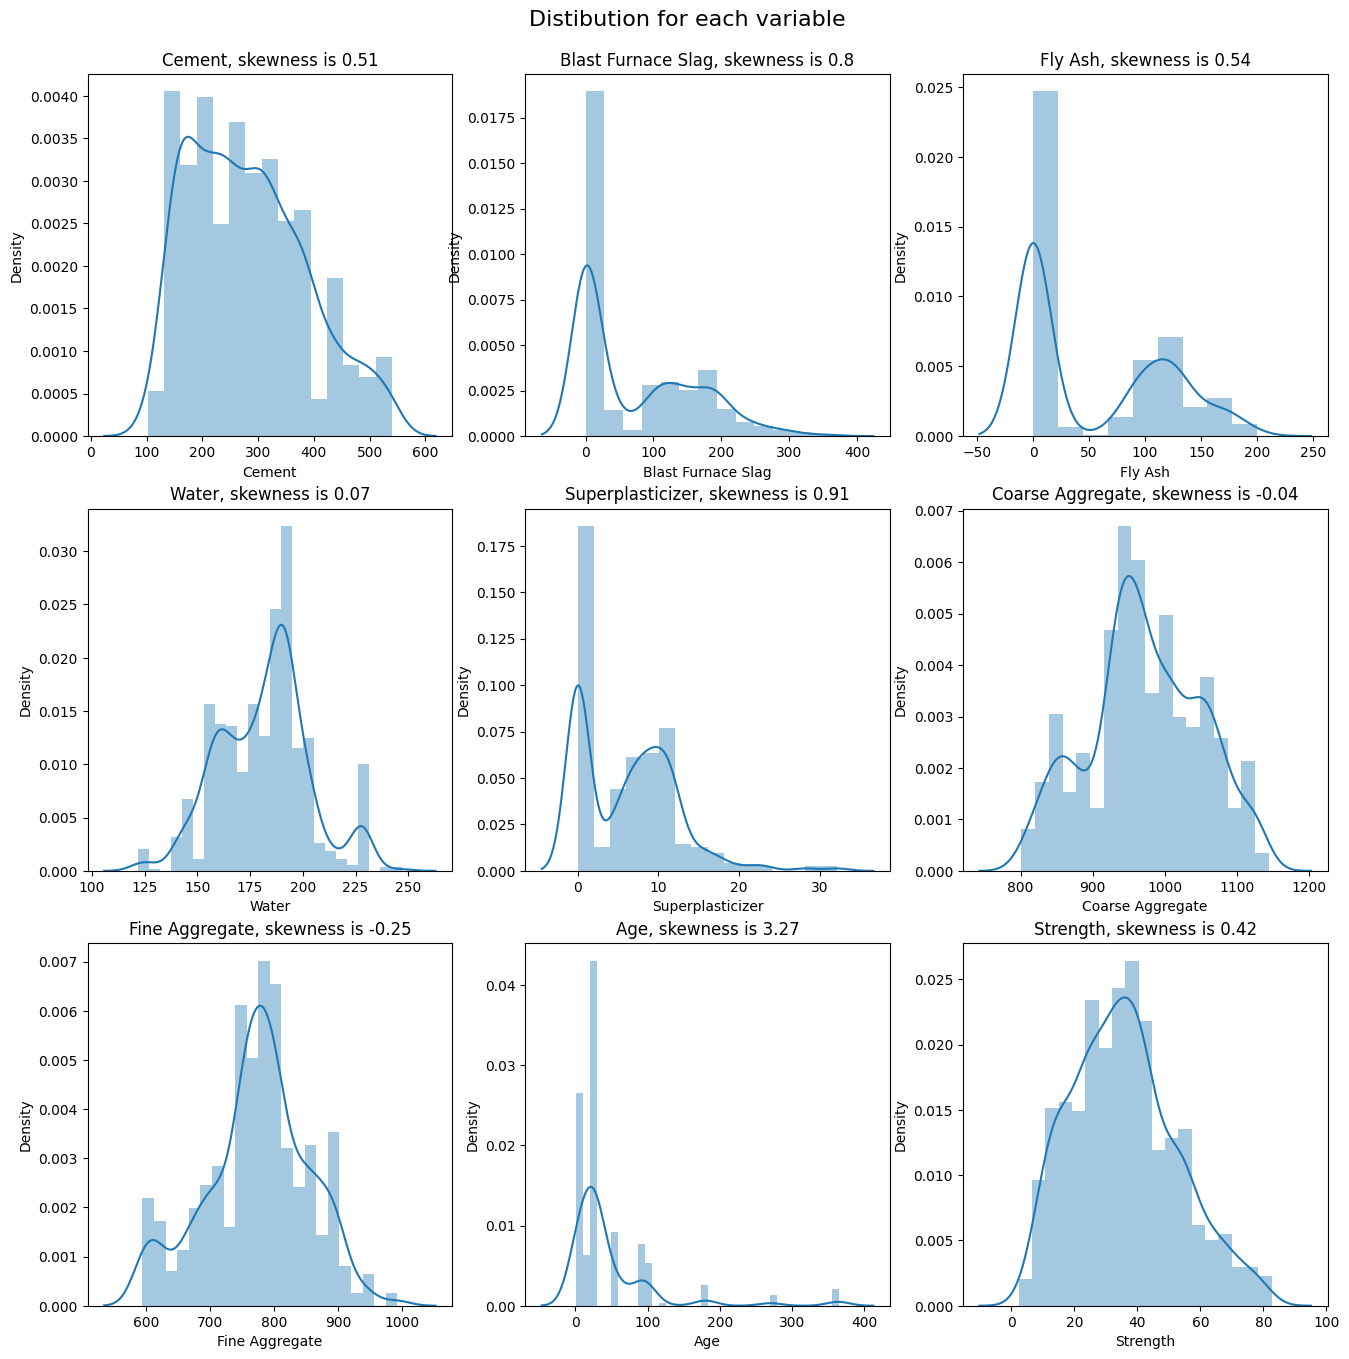

In [11]:
create_distplot(dataset=df, columns=df.columns, rows=3, cols=3, title='Distibution for each variable')

Most variables do not follow normal distribution. It would be interesting to convert the response variable into a category of 'optimal' and 'suboptimal' in order to detect any interesting patterns between the predictors and the target variable. I'll conisder the observations at the 75th percentile or greater to be good.

In [ ]:
# outliers
def boxplots_custom(dataset, columns_list, rows, cols, suptitle):
    fig, axs = plt.subplots(rows, cols, sharey=True, figsize=(16,12))
    fig.suptitle(suptitle,y=0.93, size=16)
    axs = axs.flatten()
    for i, data in enumerate(columns_list):
        if i % 3 == 0:
            axs[i].set_ylabel('The number of entries')
        sns.boxplot( data=dataset[data], orient='h', ax=axs[i])
        axs[i].set_title(data)

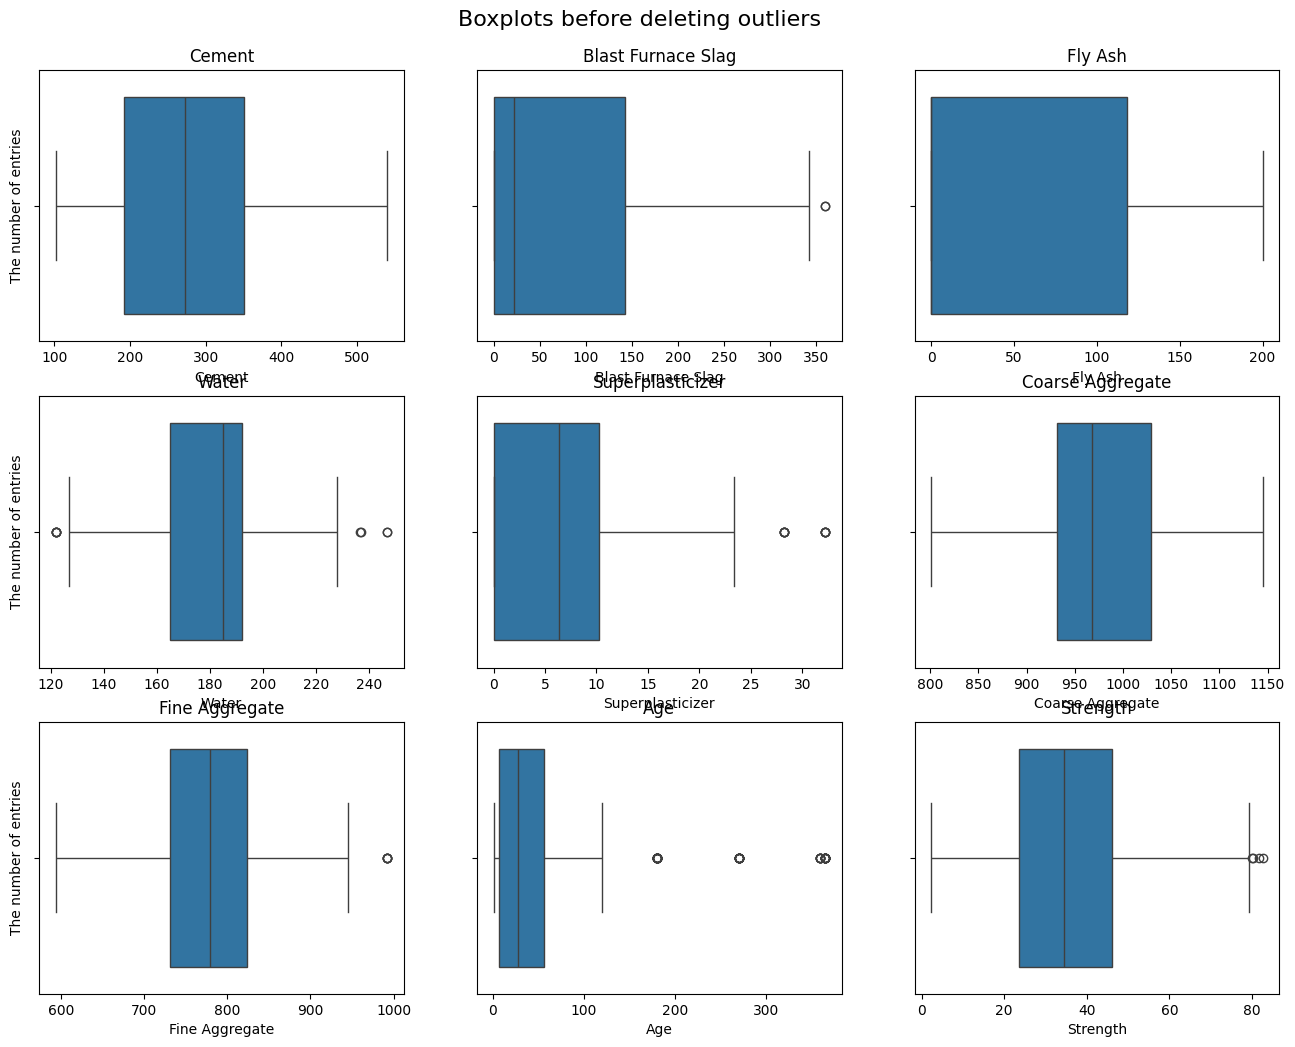

In [ ]:
boxplots_custom(dataset=df, columns_list=df.columns, rows=3, cols=3, suptitle='Boxplots before deleting outliers')

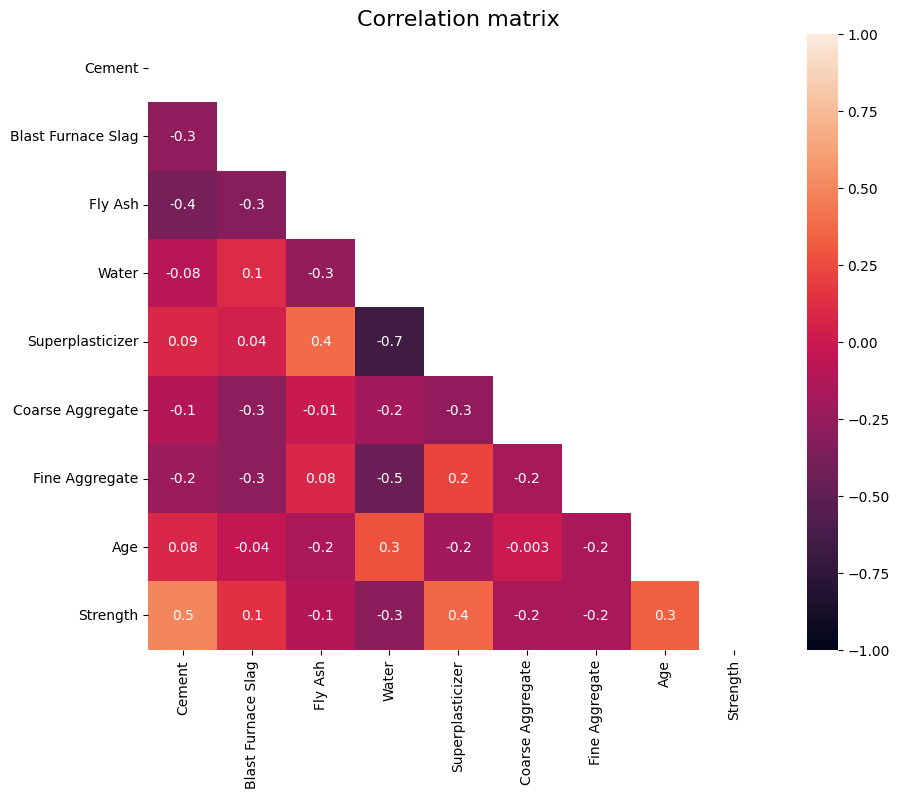

In [12]:
# calculating the correlation matrix
corr = df.corr()
matrix = np.triu(corr)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, vmax=1.0, vmin=-1.0,
            fmt='.1g', annot=True, mask = matrix)

plt.title('Correlation matrix', size=16)
plt.show()

The pearsons correlation assumes normality, linearity, homoscedasticity and no outliers. These assumptions are violated for most variables. This may be a potential reason as to why pearsons correlation won't detect nuances between predictors and the independent variables properly. Additionally, the relationship between inputs does seem to be largely non-linear. Nonetheless, cement, water, and superplastisizer do seem to be moderately correlated with strength.

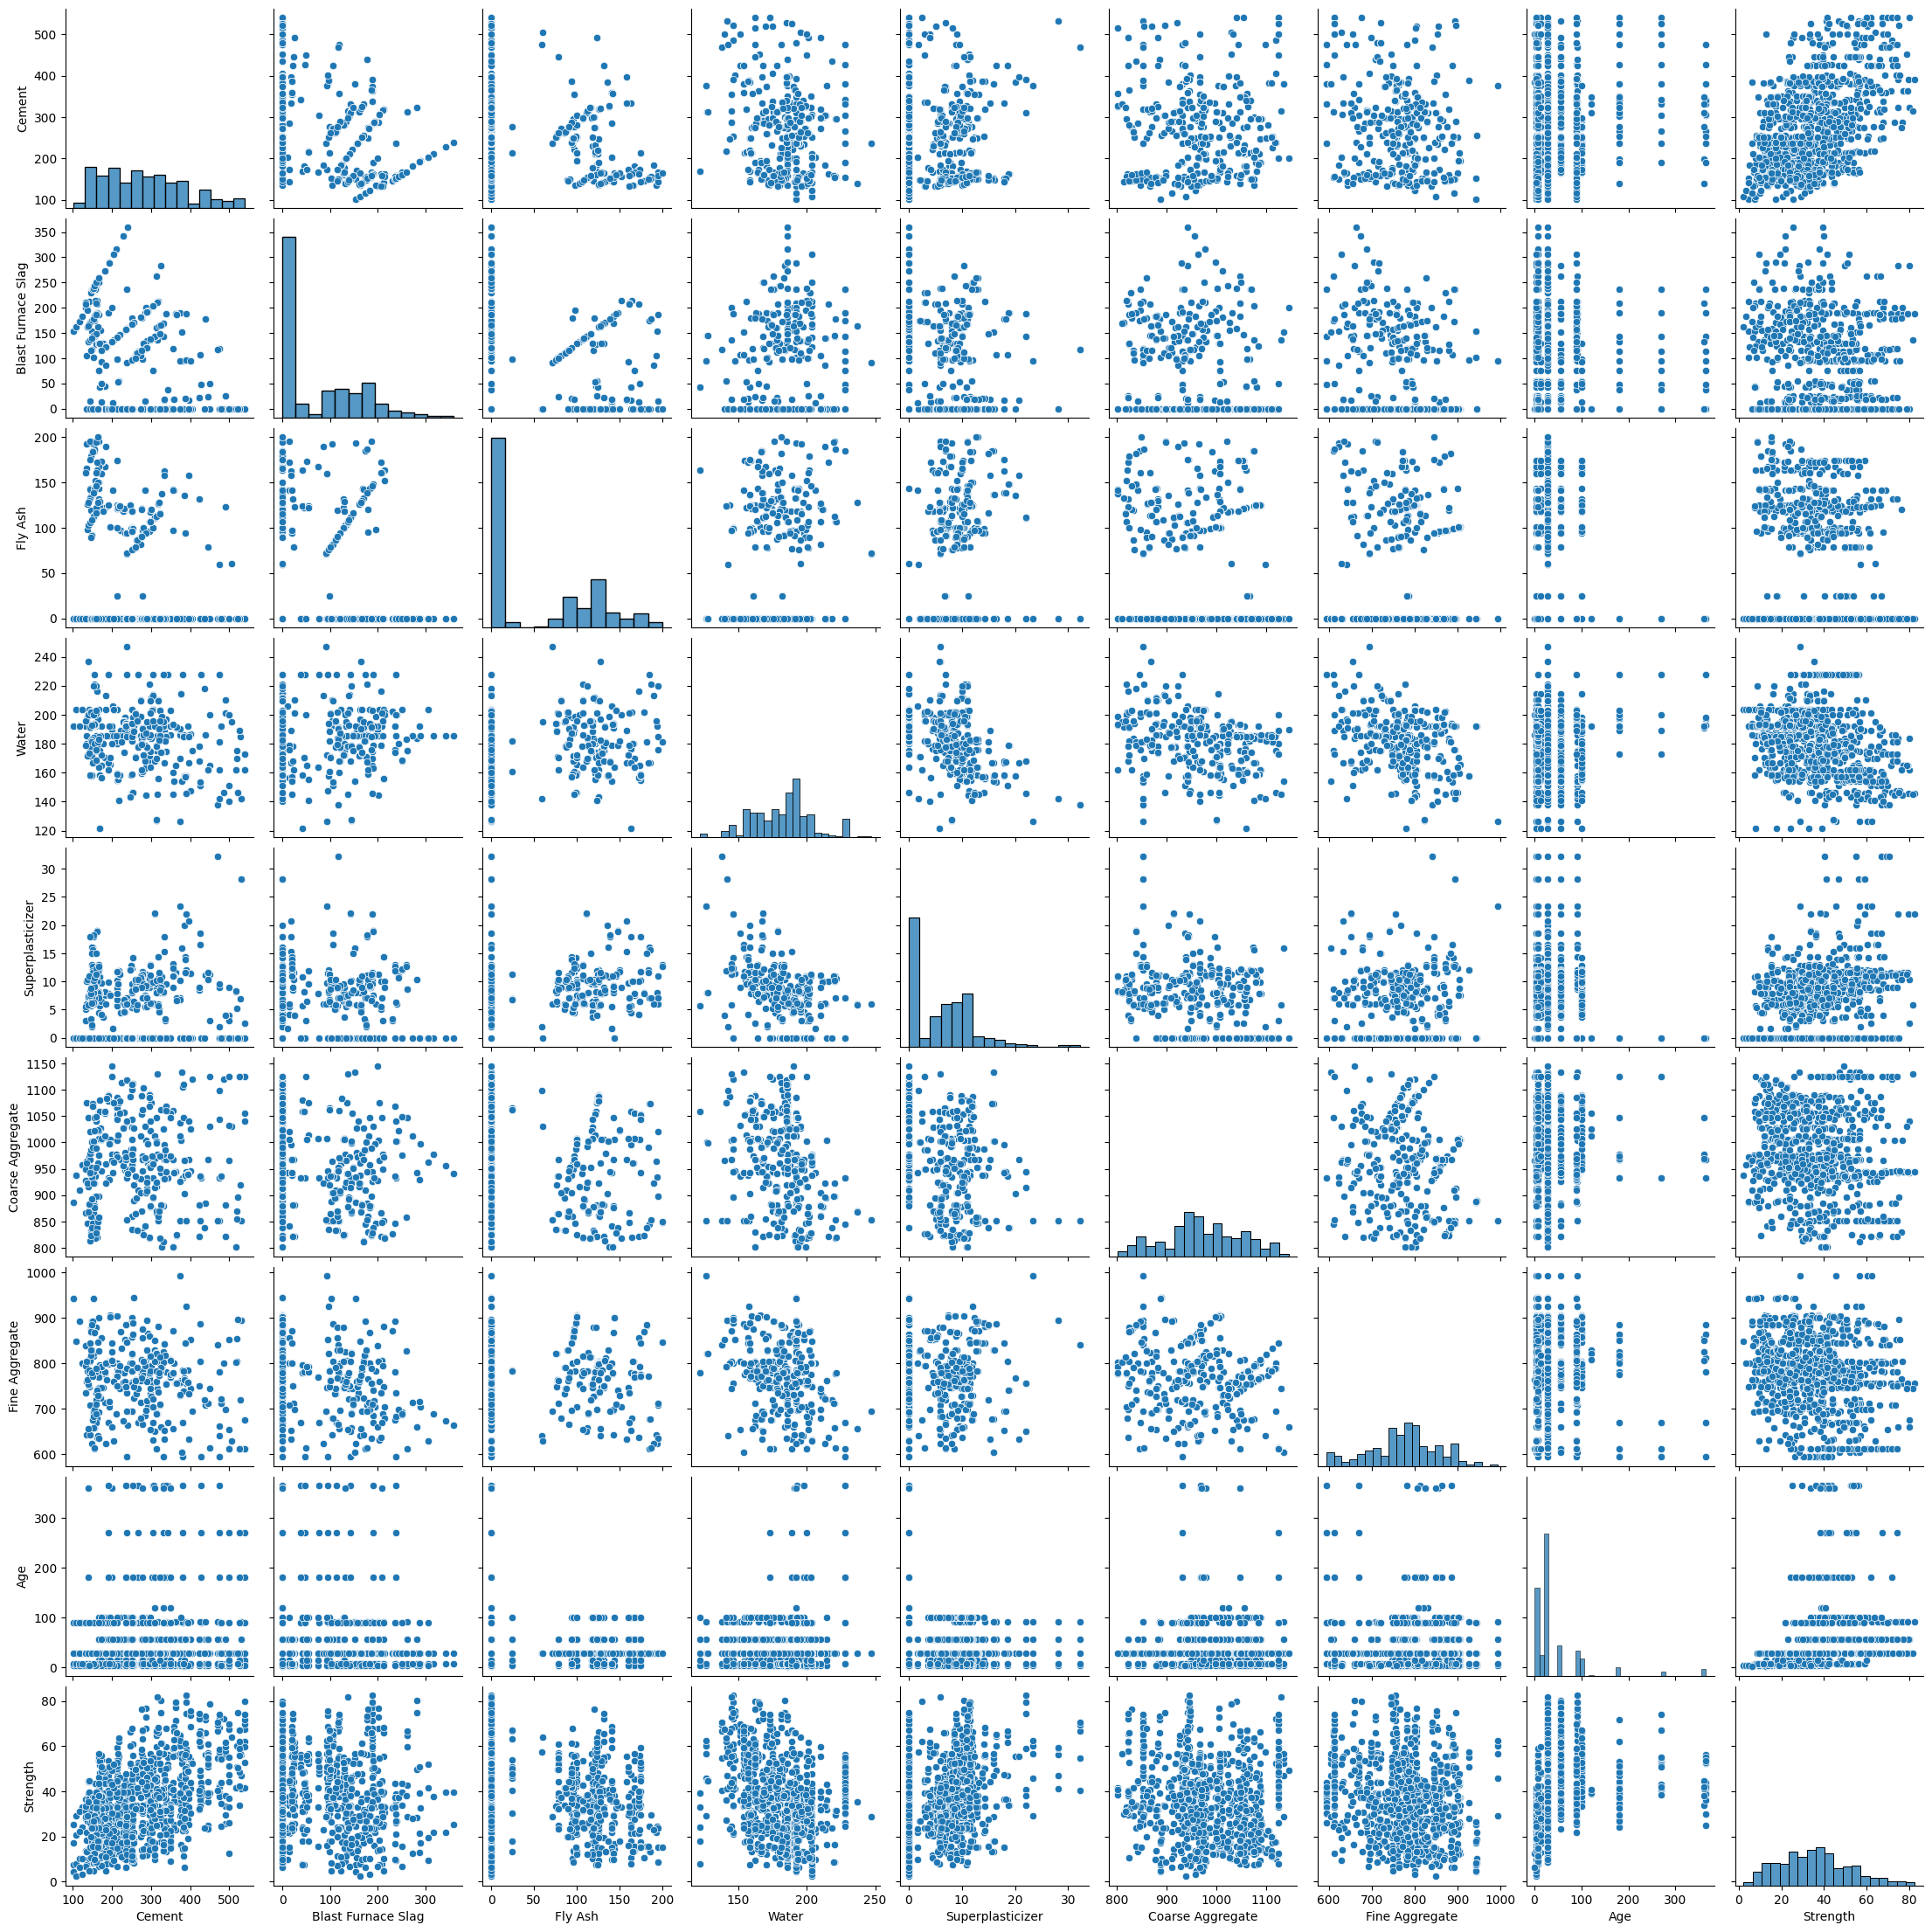

In [13]:
sns.pairplot(data=df,diag_kind="hist")
plt.show()

## Data Preprocessing

Some machine learning algorithms require features to be scaled through normalization or standardization. I will now split the dataset into training and testing and then perform standardization. This will tansform the features such that their mean and standard deviation will become 0 and 1.

In [14]:

X = df.iloc[:, :-1].values
y = df.iloc[:,-1].values

In [15]:
# Split the dataset into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,
                                                    shuffle = True,
                                                    random_state = 43)

In [16]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test =sc.transform(X_test)

In [ ]:
X_train

array([[-0.6267737 , -0.86073957,  1.90187148, ...,  1.01212601,
         0.00805866,  0.8581784 ],
       [-0.27731315, -0.86073957,  0.66901799, ..., -0.21696042,
         1.05976169, -0.504752  ],
       [-0.39028944,  0.98130096, -0.83396389, ...,  0.86138899,
        -0.4975442 , -0.28287961],
       ...,
       [ 0.23969699,  0.02084154, -0.83396389, ..., -0.53775971,
        -1.28662828,  2.12602064],
       [-0.26390918, -0.86073957,  1.02395416, ...,  0.70421023,
        -0.21038141,  0.16086518],
       [-0.63634796, -0.86073957,  0.74283215, ...,  0.43881001,
         1.58009085, -0.504752  ]])

In [19]:
X_train.shape[1]

8

## Model Building using ANN

In [ ]:
# Improving the ANN

model1 = Sequential()

# Adding the input layer and the first hidden layer
model1.add(Dense(units = 800,
                 kernel_initializer = 'uniform',
                 activation = 'relu',
                 input_shape = [X_train.shape[1]]))

# Adding the second hidden layer
model1.add(Dense(units = 1200,
                 kernel_initializer = 'uniform',
                 activation = 'relu'))

# Adding the Third hidden layer
model1.add(Dense(units = 1800, kernel_initializer = 'uniform', activation = 'relu'))

# Adding the fourth hidden layer
model1.add(Dense(units = 2000, kernel_initializer = 'uniform', activation = 'relu'))

# Adding the fifth hidden layer
model1.add(Dense(units = 3000, kernel_initializer = 'uniform', activation = 'relu'))

# Adding the output layer
model1.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'linear'))

In [ ]:
model1.summary()

In [22]:
# Compiling the ANN
model1.compile(optimizer = 'adam', loss = 'mean_squared_error')
EPOCHS  = 50
# Fitting the ANN to the Training set
history = model1.fit(X_train,
                     y_train,
                     batch_size=62 ,
                     epochs=EPOCHS ,
                     validation_split=0.1,
                     verbose = 1)

# save trained model
model1.save("trained_model_{}.h5".format(EPOCHS))

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 235ms/step - loss: 893.1692 - val_loss: 363.1379
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 228.1693 - val_loss: 218.2978
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 167.2932 - val_loss: 142.9520
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 119.5872 - val_loss: 111.1321
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 88.6822 - val_loss: 134.0582
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 88.1270 - val_loss: 73.2886
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 53.9138 - val_loss: 56.0549
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 44.2390 - val_loss: 45.3599
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 32.2363 - val_loss: 48.1096
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 32.1968 - val_loss: 36.9119
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25.2380 - val_loss: 40.8392
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s

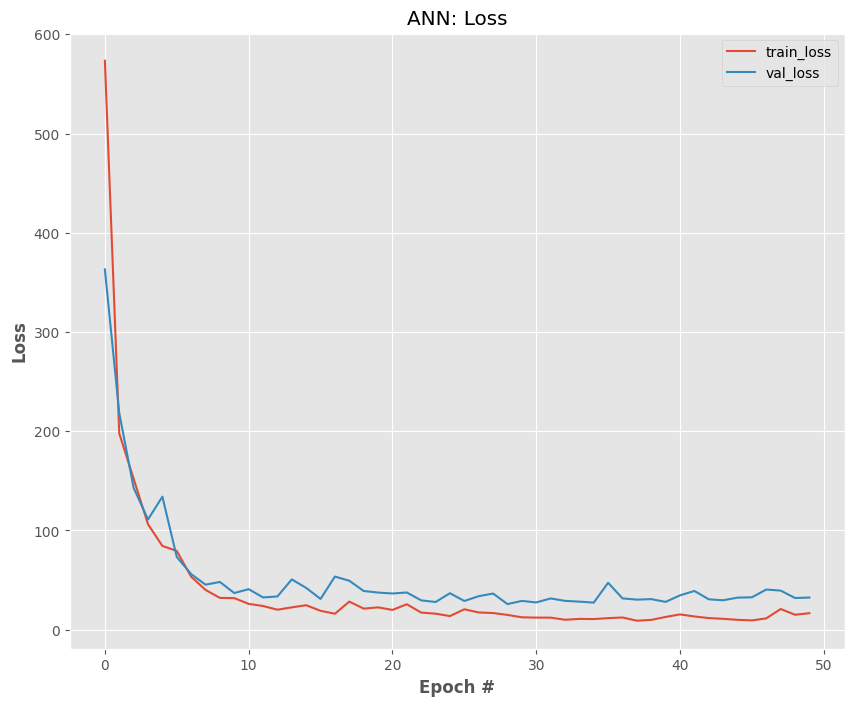

In [25]:
# plot the training and validation loss
history_df = pd.DataFrame(history.history)

N = np.arange(0, EPOCHS)
plt.style.use("ggplot")
plt.figure(figsize = [10,8])
plt.plot(N, history_df["loss"], label="train_loss")
plt.plot(N, history_df["val_loss"], label="val_loss")
plt.title("ANN: Loss")
plt.xlabel("Epoch #", weight="bold")
plt.ylabel("Loss", weight="bold")
plt.legend()
plt.show()

In [ ]:
y_pred = model1.predict(X_test) # https://justpaste.it/dx9cx

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

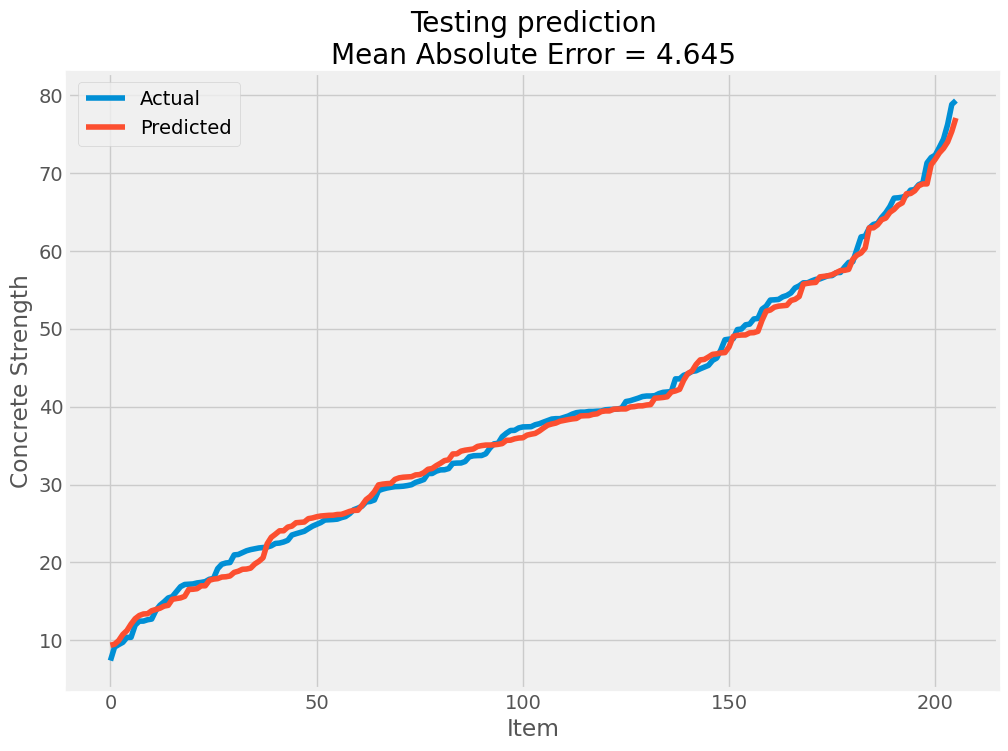

In [28]:
MAE = mae(y_test,y_pred)

plt.figure(figsize=(12,8))
with plt.style.context('fivethirtyeight'):

    plt.plot(sorted(y_test), label='Actual')
    plt.plot(sorted(y_pred), label='Predicted')

    plt.title('Testing prediction\nMean Absolute Error = {:.3f}'.format(MAE))
    plt.ylabel('Concrete Strength')
    plt.xlabel('Item')
    plt.legend()
plt.show()

## Model Finetuning

## Improving with different archtitecture

In [ ]:
model2 = keras.Sequential([
    Dense(40 , activation = 'relu' , input_shape = [X_train.shape[1]]),
    Dense(50 , activation = 'relu'),
    Dense(60 , activation = 'relu'),
    Dense(1 , activation = 'linear')
])

In [ ]:
# summary of the model
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 40)                360       
                                                                 
 dense_7 (Dense)             (None, 50)                2050      
                                                                 
 dense_8 (Dense)             (None, 60)                3060      
                                                                 
 dense_9 (Dense)             (None, 1)                 61        
                                                                 
Total params: 5531 (21.61 KB)
Trainable params: 5531 (21.61 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model2.compile(optimizer='Adam', loss = 'mean_squared_error' , )

In [ ]:
history = model2.fit(X_train,y_train,batch_size=62 , epochs=100 , validation_split=.1,verbose = 1)

Epoch 1/100
12/12 [==============================] - 2s 16ms/step - loss: 1496.9354 - val_loss: 1551.1832
Epoch 2/100
12/12 [==============================] - 0s 5ms/step - loss: 1423.6790 - val_loss: 1457.7026
Epoch 3/100
12/12 [==============================] - 0s 5ms/step - loss: 1299.4843 - val_loss: 1285.8730
Epoch 4/100
12/12 [==============================] - 0s 5ms/step - loss: 1080.5779 - val_loss: 993.8831
Epoch 5/100
12/12 [==============================] - 0s 5ms/step - loss: 744.5212 - val_loss: 605.5209
Epoch 6/100
12/12 [==============================] - 0s 5ms/step - loss: 409.4380 - val_loss: 307.4033
Epoch 7/100
12/12 [==============================] - 0s 5ms/step - loss: 254.8611 - val_loss: 269.2479
Epoch 8/100
12/12 [==============================] - 0s 5ms/step - loss: 228.0663 - val_loss: 241.3752
Epoch 9/100
12/12 [==============================] - 0s 5ms/step - loss: 204.2993 - val_loss: 227.3286
Epoch 10/100
12/12 [==============================] - 0s 5ms/step

In [ ]:
history_df = pd.DataFrame(history.history)

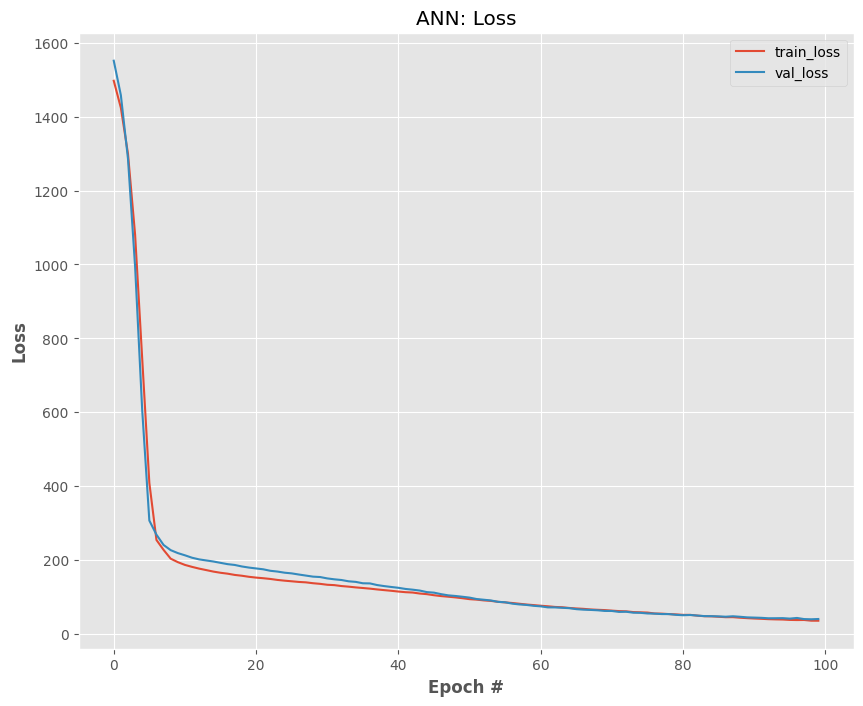

In [ ]:
# plot the training and validation loss
N = np.arange(0, 100)
plt.style.use("ggplot")
plt.figure(figsize = [10,8])
plt.plot(N, history_df["loss"], label="train_loss")
plt.plot(N, history_df["val_loss"], label="val_loss")
plt.title("ANN: Loss")
plt.xlabel("Epoch #", weight="bold")
plt.ylabel("Loss", weight="bold")
plt.legend()
plt.show()

## Prediction on Unseen Data

In [ ]:
y_pred = model2.predict(X_test)

7/7 [==============================] - 0s 2ms/step


## Model Evaluation

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7965770957671162

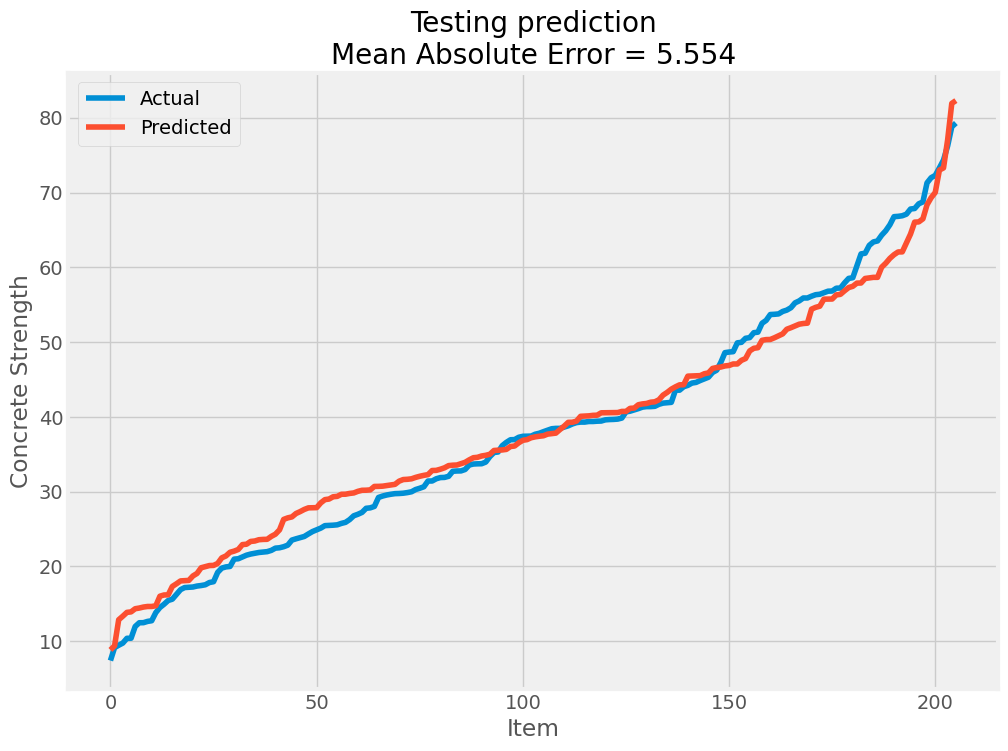

In [ ]:
MAE = mae(y_test,y_pred)

plt.figure(figsize=(12,8))
with plt.style.context('fivethirtyeight'):

    plt.plot(sorted(y_test), label='Actual')
    plt.plot(sorted(y_pred), label='Predicted')

    plt.title('Testing prediction\nMean Absolute Error = {:.3f}'.format(MAE))
    plt.ylabel('Concrete Strength')
    plt.xlabel('Item')
    plt.legend()
plt.show()

## Improving ANN with Dropout layer

In [ ]:
model3 = keras.Sequential([
    Dense(30 , activation = 'relu' , input_shape = [X_train.shape[1]]),
    Dense(40 , activation = 'relu'),
    Dropout(rate = 0.1),
    Dense(50 , activation = 'relu'),
    Dense(1 , activation = 'linear')
])

In [ ]:
model3.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 30)                270       
                                                                 
 dense_11 (Dense)            (None, 40)                1240      
                                                                 
 dropout (Dropout)           (None, 40)                0         
                                                                 
 dense_12 (Dense)            (None, 50)                2050      
                                                                 
 dense_13 (Dense)            (None, 1)                 51        
                                                                 
Total params: 3611 (14.11 KB)
Trainable params: 3611 (14.11 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Compiling the ANN
model3.compile(optimizer = 'adam', loss = 'mean_squared_error')

# Fitting the ANN to the Training set
history = model3.fit(X_train,y_train,
                          batch_size=62 ,
                          epochs=100 ,
                          validation_split=0.1,
                          verbose = 1)

Epoch 1/100
12/12 [==============================] - 1s 16ms/step - loss: 1502.0410 - val_loss: 1565.8300
Epoch 2/100
12/12 [==============================] - 0s 5ms/step - loss: 1454.5292 - val_loss: 1511.8572
Epoch 3/100
12/12 [==============================] - 0s 5ms/step - loss: 1388.4407 - val_loss: 1424.9871
Epoch 4/100
12/12 [==============================] - 0s 5ms/step - loss: 1275.9014 - val_loss: 1280.0618
Epoch 5/100
12/12 [==============================] - 0s 4ms/step - loss: 1097.6830 - val_loss: 1055.6898
Epoch 6/100
12/12 [==============================] - 0s 4ms/step - loss: 827.0782 - val_loss: 760.0807
Epoch 7/100
12/12 [==============================] - 0s 4ms/step - loss: 529.6435 - val_loss: 473.1989
Epoch 8/100
12/12 [==============================] - 0s 4ms/step - loss: 316.9619 - val_loss: 328.0408
Epoch 9/100
12/12 [==============================] - 0s 4ms/step - loss: 256.5004 - val_loss: 278.5074
Epoch 10/100
12/12 [==============================] - 0s 5ms/s

12/12 [==============================] - 0s 7ms/step - loss: 43.5386 - val_loss: 47.7897
Epoch 81/100
12/12 [==============================] - 0s 7ms/step - loss: 44.0358 - val_loss: 46.8452
Epoch 82/100
12/12 [==============================] - 0s 8ms/step - loss: 41.9187 - val_loss: 49.4670
Epoch 83/100
12/12 [==============================] - 0s 7ms/step - loss: 42.2130 - val_loss: 46.5711
Epoch 84/100
12/12 [==============================] - 0s 7ms/step - loss: 43.4417 - val_loss: 47.3672
Epoch 85/100
12/12 [==============================] - 0s 7ms/step - loss: 43.0314 - val_loss: 47.0658
Epoch 86/100
12/12 [==============================] - 0s 7ms/step - loss: 40.9370 - val_loss: 45.1809
Epoch 87/100
12/12 [==============================] - 0s 7ms/step - loss: 41.3377 - val_loss: 45.5286
Epoch 88/100
12/12 [==============================] - 0s 8ms/step - loss: 40.8178 - val_loss: 45.8802
Epoch 89/100
12/12 [==============================] - 0s 6ms/step - loss: 40.6721 - val_loss: 4

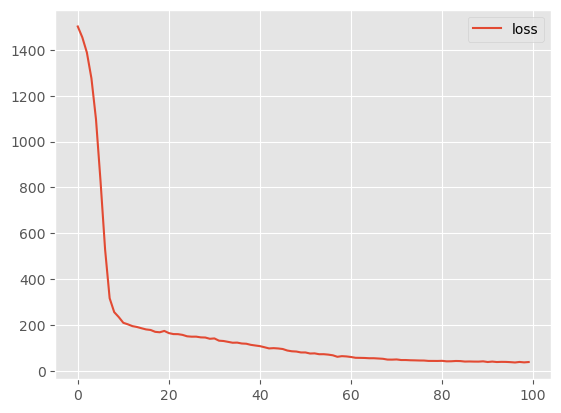

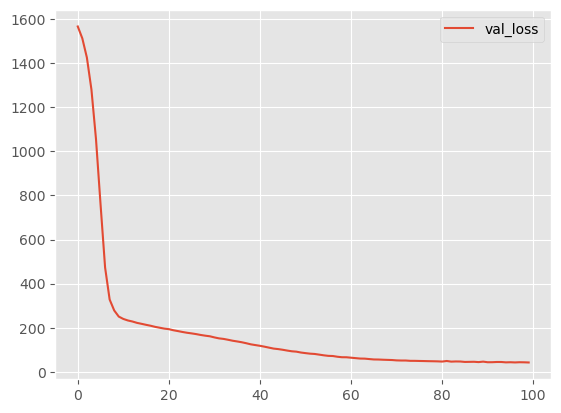

In [ ]:
history_df = pd.DataFrame(history.history)

In [ ]:
# plot the training and validation loss
N = np.arange(0, 100)
plt.style.use("ggplot")
plt.figure(figsize = [10,8])
plt.plot(N, history_df["loss"], label="train_loss")
plt.plot(N, history_df["val_loss"], label="val_loss")
plt.title("ANN: Loss")
plt.xlabel("Epoch #", weight="bold")
plt.ylabel("Loss", weight="bold")
plt.legend()
plt.show()

In [ ]:
y_pred = model3.predict(X_test)

7/7 [==============================] - 0s 1ms/step


In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8116076485006098

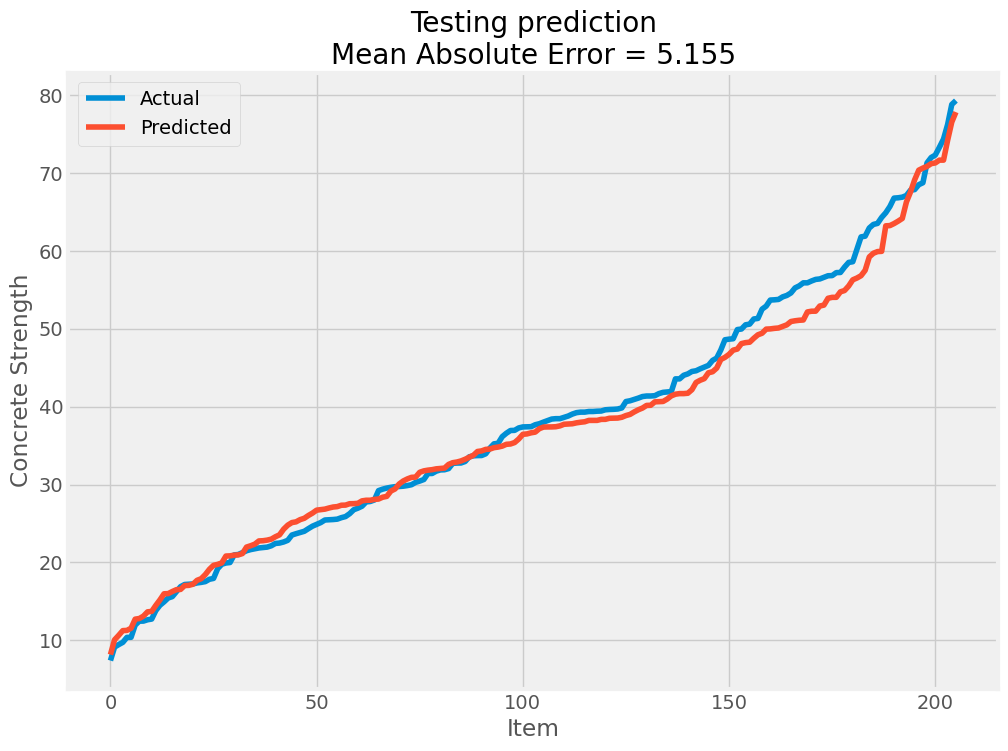

In [ ]:
MAE = mae(y_test,y_pred)

plt.figure(figsize=(12,8))
with plt.style.context('fivethirtyeight'):

    plt.plot(sorted(y_test), label='Actual')
    plt.plot(sorted(y_pred), label='Predicted')

    plt.title('Testing prediction\nMean Absolute Error = {:.3f}'.format(MAE))
    plt.ylabel('Concrete Strength')
    plt.xlabel('Item')
    plt.legend()
plt.show()

# Conclusion

We trained three ANN model using Different Fine Tuning Technique, from all the three models 2nd model is giving better performance so will select the second model for Deployment